# OVRO-LWA source metacatalog

Identify sources in OVRO-LWA wide-field FITS images with **PyBDSF**, then fuse
per-image catalogs into a **metacatalog** with one entry per unique sky position.

Pipeline (library: `lwa_catalog.create` + Parquet I/O):

1. **Discover** FITS under `FITS_ROOT` (LST hour + color band from filenames).
2. **Detect** sources per image (`detect_sources`).
3. **LST merge** within each band (`merge_lst_metacatalog`).
4. **Band merge** sequential Full→Blue→Green→Red (`build_global_metacatalog`).

Catalogs are written as **Parquet** under `OUTPUT_DIR` via `CatalogLayout`.
Set `REUSE_CACHED_CATALOGS = True` to skip PyBDSF / LST merge when caches exist.
Set `MIGRATE_LEGACY_CSV = True` once to convert old CSV/FITS catalog trees.


In [1]:
from __future__ import annotations

from pathlib import Path

import pandas as pd

from lwa_catalog import CatalogLayout, migrate_output_dir
from lwa_catalog.create import (
    build_global_metacatalog,
    detect_sources,
    discover_fits_files,
    discovered_slots,
    lst_hours_from_discovery,
    merge_lst_metacatalog,
)
from lwa_catalog.io import (
    lst_merged_cache_complete,
    read_all_lst_merged,
    read_sources_catalog,
    sources_cache_complete,
    write_lst_merged,
    write_metacatalog,
    write_sources_catalog,
)

# --- user configuration ---------------------------------------------------
#FITS_ROOT = Path("/fast/claw")  # directory containing FITS images (searched recursively)
FITS_ROOT = Path("/lustre/pipeline/exopipe/phase3/coadd/Run_MASTERS1_20241218-20250827")
# Glob(s) relative to FITS_ROOT (rglob). Default: all .fits. Examples:
#   "I_*_deep_Taper_R0_*.fits"  or  ("*.fits", "*_LST*h_*.fits")
#FITS_GLOB: str | tuple[str, ...] = "*.fits"
FITS_GLOB = "??h_[RGBF]*//*_I_deep_Taper_Robust+0.0_dewarped*fits"
OUTPUT_DIR = Path("/fast/claw/metacatalog_coadd")  # Parquet catalog tree

# PyBDSF detection parameters
BDSF_KW = dict(
    thresh="hard",
    thresh_isl=7.0,
    thresh_pix=4.0,
    atrous_do=False,
    psf_vary_do=False,
    quiet=True,
    ncores=16,
)

# Optional subset of LST hour bins (e.g. ["01h", "02h"]). None = all discovered.
LST_HOURS_OVERRIDE: list[str] | None = None
ASSOC_BANDS = ("Blue", "Green", "Red")

# When True, skip PyBDSF / LST merge if matching Parquet files already exist
REUSE_CACHED_CATALOGS = True

# One-time CSV/FITS → Parquet migration (no-op if only Parquet is present)
MIGRATE_LEGACY_CSV = False

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
layout = CatalogLayout(OUTPUT_DIR)

if MIGRATE_LEGACY_CSV:
    migrated = migrate_output_dir(layout)
    print(f"Migrated {len(migrated)} legacy catalog file(s) under {OUTPUT_DIR}")


## Filename parsing

Discover FITS under `FITS_ROOT` and parse LST hour / color band from filenames
(`lwa_catalog.create.discover`). Band names are defined as notebook constants below.


In [2]:
# Explicit catalog constants (notebook-local; passed into library APIs below)
COLOR_BANDS = ("Full", "Blue", "Green", "Red")


In [3]:
_fits_patterns = (FITS_GLOB,) if isinstance(FITS_GLOB, str) else tuple(FITS_GLOB)
fits_files = discover_fits_files(FITS_ROOT, patterns=_fits_patterns)
_discovered_lst_hours = lst_hours_from_discovery(fits_files)
LST_HOURS = list(LST_HOURS_OVERRIDE) if LST_HOURS_OVERRIDE is not None else _discovered_lst_hours
fits_by_slot = discovered_slots(fits_files)
summary = pd.DataFrame(
    {
        "path": [m.path.name for m in fits_files],
        "lst_hour": [m.lst_hour for m in fits_files],
        "band": [m.band for m in fits_files],
        "time_key": [m.time_key for m in fits_files],
    }
)
print(f"Found {len(fits_files)} FITS files under {FITS_ROOT} matching {list(_fits_patterns)}")
print(
    f"LST hours from discovery ({len(_discovered_lst_hours)}): "
    f"{', '.join(_discovered_lst_hours)}"
)
if LST_HOURS_OVERRIDE is not None:
    print(f"LST hours in use (override): {', '.join(LST_HOURS)}")
else:
    print(f"LST hours in use (all discovered): {', '.join(LST_HOURS)}")
summary.sort_values(["lst_hour", "band"]).reset_index(drop=True)


Found 93 FITS files under /lustre/pipeline/exopipe/phase3/coadd/Run_MASTERS1_20241218-20250827 matching ['??h_[RGBF]*//*_I_deep_Taper_Robust+0.0_dewarped*fits']
LST hours from discovery (24): 00h, 01h, 02h, 03h, 04h, 05h, 06h, 07h, 08h, 09h, 10h, 11h, 12h, 13h, 14h, 15h, 16h, 17h, 18h, 19h, 20h, 21h, 22h, 23h
LST hours in use (all discovered): 00h, 01h, 02h, 03h, 04h, 05h, 06h, 07h, 08h, 09h, 10h, 11h, 12h, 13h, 14h, 15h, 16h, 17h, 18h, 19h, 20h, 21h, 22h, 23h


,path,lst_hour,band,time_key
0,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,00h,Blue,None
1,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,00h,Full,None
2,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,00h,Green,None
3,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,00h,Red,None
4,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,01h,Blue,None
...,...,...,...,...
88,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,22h,Blue,None
89,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,22h,Full,None
90,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,22h,Green,None
91,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,22h,Red,None


## PyBDSF source detection

Detect sources per image with PyBDSF (`lwa_catalog.create.detect`).
`GAUL_COLUMNS` and `BDSF_KW` are notebook-local; cache helpers wrap Parquet I/O.


In [4]:
GAUL_COLUMNS = [
    "RA",
    "DEC",
    "E_RA",
    "E_DEC",
    "Total_flux",
    "E_Total_flux",
    "Peak_flux",
    "E_Peak_flux",
    "Maj",
    "E_Maj",
    "Min",
    "E_Min",
    "PA",
    "E_PA",
    "DC_Maj",
    "DC_Min",
    "DC_PA",
    "S_Code",
    "Gaus_id",
    "Isl_id",
    "Source_id",
]


def all_sources_cached() -> bool:
    """True when every discovered (lst, band) slot has a sources Parquet file."""
    return sources_cache_complete(layout, sorted(fits_by_slot))


def all_lst_merged_cached() -> bool:
    """True when every color band has an LST-merged Parquet file."""
    return lst_merged_cache_complete(layout, COLOR_BANDS)


def load_sources_catalog(lst_hour: str, band: str) -> pd.DataFrame:
    """Load a per-image sources Parquet catalog, backfilling beam from the FITS image."""
    meta = fits_by_slot[(lst_hour, band)]
    return read_sources_catalog(layout, lst_hour, band, fits_path=meta.path)


def load_per_image_catalogs_from_disk() -> dict[tuple[str, str], pd.DataFrame]:
    """Load all per-image catalogs from OUTPUT_DIR when every slot is cached."""
    catalogs: dict[tuple[str, str], pd.DataFrame] = {}
    for lst_hour, band in sorted(fits_by_slot):
        catalogs[(lst_hour, band)] = load_sources_catalog(lst_hour, band)
    return catalogs


def load_lst_merged_from_disk() -> dict[str, pd.DataFrame]:
    """Load LST-merged per-band catalogs from OUTPUT_DIR."""
    return read_all_lst_merged(layout, COLOR_BANDS)


In [5]:
per_image_catalogs: dict[tuple[str, str], pd.DataFrame] = {}

for (lst_hour, band), meta in sorted(fits_by_slot.items()):
    key = (lst_hour, band)
    out_path = layout.sources(lst_hour, band)

    if REUSE_CACHED_CATALOGS and out_path.is_file():
        catalog = load_sources_catalog(lst_hour, band)
        per_image_catalogs[key] = catalog
        print(f"Cached {key}: {len(catalog)} sources <- {out_path.name}")
        continue

    catalog = detect_sources(meta, bdsf_kw=BDSF_KW, gaul_columns=GAUL_COLUMNS)
    per_image_catalogs[key] = catalog
    write_sources_catalog(catalog, layout, lst_hour, band)
    print(f"Detected {key}: {len(catalog)} sources -> {out_path.name}")


Cached ('00h', 'Blue'): 5401 sources <- sources_00h_Blue.parquet
Cached ('00h', 'Full'): 2772 sources <- sources_00h_Full.parquet
Cached ('00h', 'Green'): 2823 sources <- sources_00h_Green.parquet
Cached ('00h', 'Red'): 980 sources <- sources_00h_Red.parquet
Cached ('01h', 'Blue'): 5235 sources <- sources_01h_Blue.parquet
Cached ('01h', 'Full'): 2829 sources <- sources_01h_Full.parquet
Cached ('01h', 'Green'): 2992 sources <- sources_01h_Green.parquet
Cached ('01h', 'Red'): 1030 sources <- sources_01h_Red.parquet
Cached ('02h', 'Blue'): 5601 sources <- sources_02h_Blue.parquet
Cached ('02h', 'Full'): 2919 sources <- sources_02h_Full.parquet
Cached ('02h', 'Green'): 3057 sources <- sources_02h_Green.parquet
Cached ('02h', 'Red'): 1060 sources <- sources_02h_Red.parquet
Cached ('03h', 'Blue'): 5756 sources <- sources_03h_Blue.parquet
Cached ('03h', 'Full'): 2897 sources <- sources_03h_Full.parquet
Cached ('03h', 'Green'): 2979 sources <- sources_03h_Green.parquet
Cached ('03h', 'Red'): 1

## Metacatalog fusion

LST merge within each band, then sequential Full→Blue→Green→Red association
(`lwa_catalog.create.merge`). Band field lists and spectral-index inputs come from
`lwa_catalog.constants` (`BAND_FIELDS` includes `E_Total_flux` for `E_alpha_*`).


In [6]:
from lwa_catalog.constants import BAND_FIELDS

# BAND_FIELDS must include E_Total_flux so associated errors propagate into
# E_Total_flux_{band} and then E_alpha_RG / E_alpha_GB.
assert "E_Total_flux" in BAND_FIELDS


In [7]:
lst_merged: dict[str, pd.DataFrame] = {}

if REUSE_CACHED_CATALOGS and all_lst_merged_cached():
    lst_merged = load_lst_merged_from_disk()
    for band in COLOR_BANDS:
        print(
            f"LST merge ({band}): loaded {len(lst_merged[band])} sources from "
            f"{layout.lst_merged(band).name}"
        )
else:
    if not per_image_catalogs and REUSE_CACHED_CATALOGS and all_sources_cached():
        per_image_catalogs.update(load_per_image_catalogs_from_disk())
        print(f"Loaded {len(per_image_catalogs)} per-image catalogs from {OUTPUT_DIR}")

    for band in COLOR_BANDS:
        band_catalogs = [
            per_image_catalogs[(lst, band)]
            for lst in LST_HOURS
            if (lst, band) in per_image_catalogs
        ]
        merged = merge_lst_metacatalog(band_catalogs, band=band)
        lst_merged[band] = merged
        out_path = write_lst_merged(merged, layout, band)
        print(f"LST merge ({band}): {len(merged)} sources -> {out_path}")

metacatalog = build_global_metacatalog(
    lst_merged,
    assoc_bands=ASSOC_BANDS,
    band_fields=BAND_FIELDS,
    color_bands=COLOR_BANDS,
)
meta_path = write_metacatalog(metacatalog, layout)

if per_image_catalogs:
    n_inputs = sum(len(df) for df in per_image_catalogs.values())
    input_desc = f"{n_inputs} per-image detections"
else:
    n_inputs = sum(int(df["n_lst_contributions"].sum()) for df in lst_merged.values())
    input_desc = f"{n_inputs} LST-merged rows (cached)"
print(f"\nGlobal metacatalog: {len(metacatalog)} sources from {input_desc}")
print(f"Wrote {meta_path}")
metacatalog.head(10)


LST merge (Full): 9258 sources -> /fast/claw/metacatalog_coadd/metacatalog_lst_Full.parquet
LST merge (Blue): 17982 sources -> /fast/claw/metacatalog_coadd/metacatalog_lst_Blue.parquet
LST merge (Green): 9423 sources -> /fast/claw/metacatalog_coadd/metacatalog_lst_Green.parquet
LST merge (Red): 3506 sources -> /fast/claw/metacatalog_coadd/metacatalog_lst_Red.parquet

Global metacatalog: 17800 sources from 238183 per-image detections
Wrote /fast/claw/metacatalog_coadd/metacatalog.parquet


,meta_id,origin_band,bands_present,RA,DEC,Peak_flux,Total_flux,Maj,Min,PA,...,n_assoc_Red,BMAJ_full,source_file_Full,source_file_Blue,source_file_Green,source_file_Red,alpha_RG,E_alpha_RG,alpha_GB,E_alpha_GB
0,0,Full,"Full,Blue,Green,Red",252.783208,4.988116,365.663162,300.599426,0.213967,0.171186,43.372883,...,1,0.230495,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,0.052779,0.011854,-11.204749,0.120126
1,1,Full,"Full,Blue,Green,Red",139.523952,-12.107700,276.074222,208.307001,0.216689,0.211570,57.357736,...,1,0.225297,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,-7.288133,0.115521,-3.627133,0.168857
2,2,Full,"Full,Blue,Green,Red",69.275337,29.672964,244.740156,374.459579,0.272094,0.201281,39.426515,...,1,0.217415,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,-0.722770,0.007104,-2.095139,0.004772
3,3,Full,"Full,Blue,Green,Red",260.126249,-0.997670,163.993429,149.756918,0.236393,0.185964,48.253414,...,2,0.230495,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,-2.362700,0.022025,-3.986790,0.072059
4,4,Full,"Full,Blue,Green,Red",6.347919,64.146244,154.178437,156.005577,0.235884,0.186792,46.465689,...,1,0.226296,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,-1.814845,0.016458,-9.392475,0.264992
5,5,Full,"Full,Blue,Green,Red",49.947681,41.505314,142.114649,111.084298,0.201799,0.151785,45.923001,...,1,0.230802,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,-2.587868,0.012207,-0.313395,0.010596
6,6,Full,"Full,Blue,Green,Red",76.171778,38.099024,133.333919,97.259269,0.181262,0.140699,38.142203,...,1,0.217415,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,-0.773515,0.012985,-2.008041,0.009186
7,7,Full,"Full,Blue,Green,Red",303.611847,23.584427,115.830570,89.081987,0.204157,0.150832,41.565005,...,1,0.235147,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,-0.948982,0.022014,-1.043338,0.013590
8,8,Full,"Full,Blue,Green,Red",123.400818,48.216455,107.472577,78.364744,0.196808,0.144914,40.760812,...,1,0.230177,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,-0.754413,0.021678,-9.100587,0.199805
9,9,Full,"Full,Blue,Green,Red",284.113773,1.426594,107.244296,231.870395,0.373870,0.271229,155.960865,...,2,0.234924,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,-0.952585,0.033907,-2.020316,0.031343


In [8]:
# LST merge yield (Full band)
full_lst = lst_merged["Full"]
multi_lst = full_lst[full_lst["n_lst_contributions"] > 1].sort_values("n_lst_contributions", ascending=False)
print(f"Full-band sources after LST merge: {len(full_lst)}")
print(f"  seen in multiple LST hours: {len(multi_lst)}")
if len(multi_lst):
    display(multi_lst.head(10)[["RA", "DEC", "Peak_flux", "n_lst_contributions", "lst_hours", "representative_lst"]])

# Global band merge
print(f"\nGlobal rows by origin_band:")
print(metacatalog["origin_band"].value_counts())

full_with_color = metacatalog[
    (metacatalog["origin_band"] == "Full")
    & (metacatalog[[f"n_assoc_{b}" for b in ASSOC_BANDS]].max(axis=1) > 0)
]
print(f"Full-seeded rows with at least one color-band association: {len(full_with_color)}")
metacatalog.head(10)[["meta_id", "RA", "DEC", "origin_band", "Peak_flux", "lst_hours", "n_assoc_Blue", "n_assoc_Green", "n_assoc_Red"]]

Full-band sources after LST merge: 9258
  seen in multiple LST hours: 8295


,RA,DEC,Peak_flux,n_lst_contributions,lst_hours,representative_lst
2,69.275337,29.672964,244.740156,52,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",05h
4,6.347919,64.146244,154.178437,46,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",00h
1,139.523952,-12.107700,276.074222,43,"04h,05h,06h,07h,08h,09h,10h,11h,12h,13h",09h
82,280.565578,79.772389,36.409813,42,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",19h
0,252.783208,4.988116,365.663162,41,"11h,12h,13h,14h,15h,16h,17h,18h,19h,20h,21h",17h
404,83.531344,22.081290,18.896768,39,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",06h
5,49.947681,41.505314,142.114649,37,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",03h
117,35.769238,86.313467,32.702211,36,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",02h
6,76.171778,38.099024,133.333919,36,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",05h
55,319.592753,60.806127,43.499602,33,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",21h



Global rows by origin_band:
origin_band
Full     9258
Blue     8355
Green     144
Red        43
Name: count, dtype: int64
Full-seeded rows with at least one color-band association: 9157


,meta_id,RA,DEC,origin_band,Peak_flux,lst_hours,n_assoc_Blue,n_assoc_Green,n_assoc_Red
0,0,252.783208,4.988116,Full,365.663162,"11h,12h,13h,14h,15h,16h,17h,18h,19h,20h,21h",6,2,1
1,1,139.523952,-12.107700,Full,276.074222,"04h,05h,06h,07h,08h,09h,10h,11h,12h,13h",3,2,1
2,2,69.275337,29.672964,Full,244.740156,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",2,1,1
3,3,260.126249,-0.997670,Full,163.993429,"12h,13h,14h,15h,16h,17h,18h,19h,20h,21h",2,2,2
4,4,6.347919,64.146244,Full,154.178437,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",2,1,1
5,5,49.947681,41.505314,Full,142.114649,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",2,1,1
6,6,76.171778,38.099024,Full,133.333919,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",2,1,1
7,7,303.611847,23.584427,Full,115.830570,"00h,01h,02h,14h,15h,16h,17h,18h,19h,20h,21h,22h",1,1,1
8,8,123.400818,48.216455,Full,107.472577,"00h,01h,02h,03h,04h,05h,06h,07h,08h,09h,10h,11...",2,1,1
9,9,284.113773,1.426594,Full,107.244296,"14h,15h,16h,17h,18h,19h,20h,21h",4,2,2


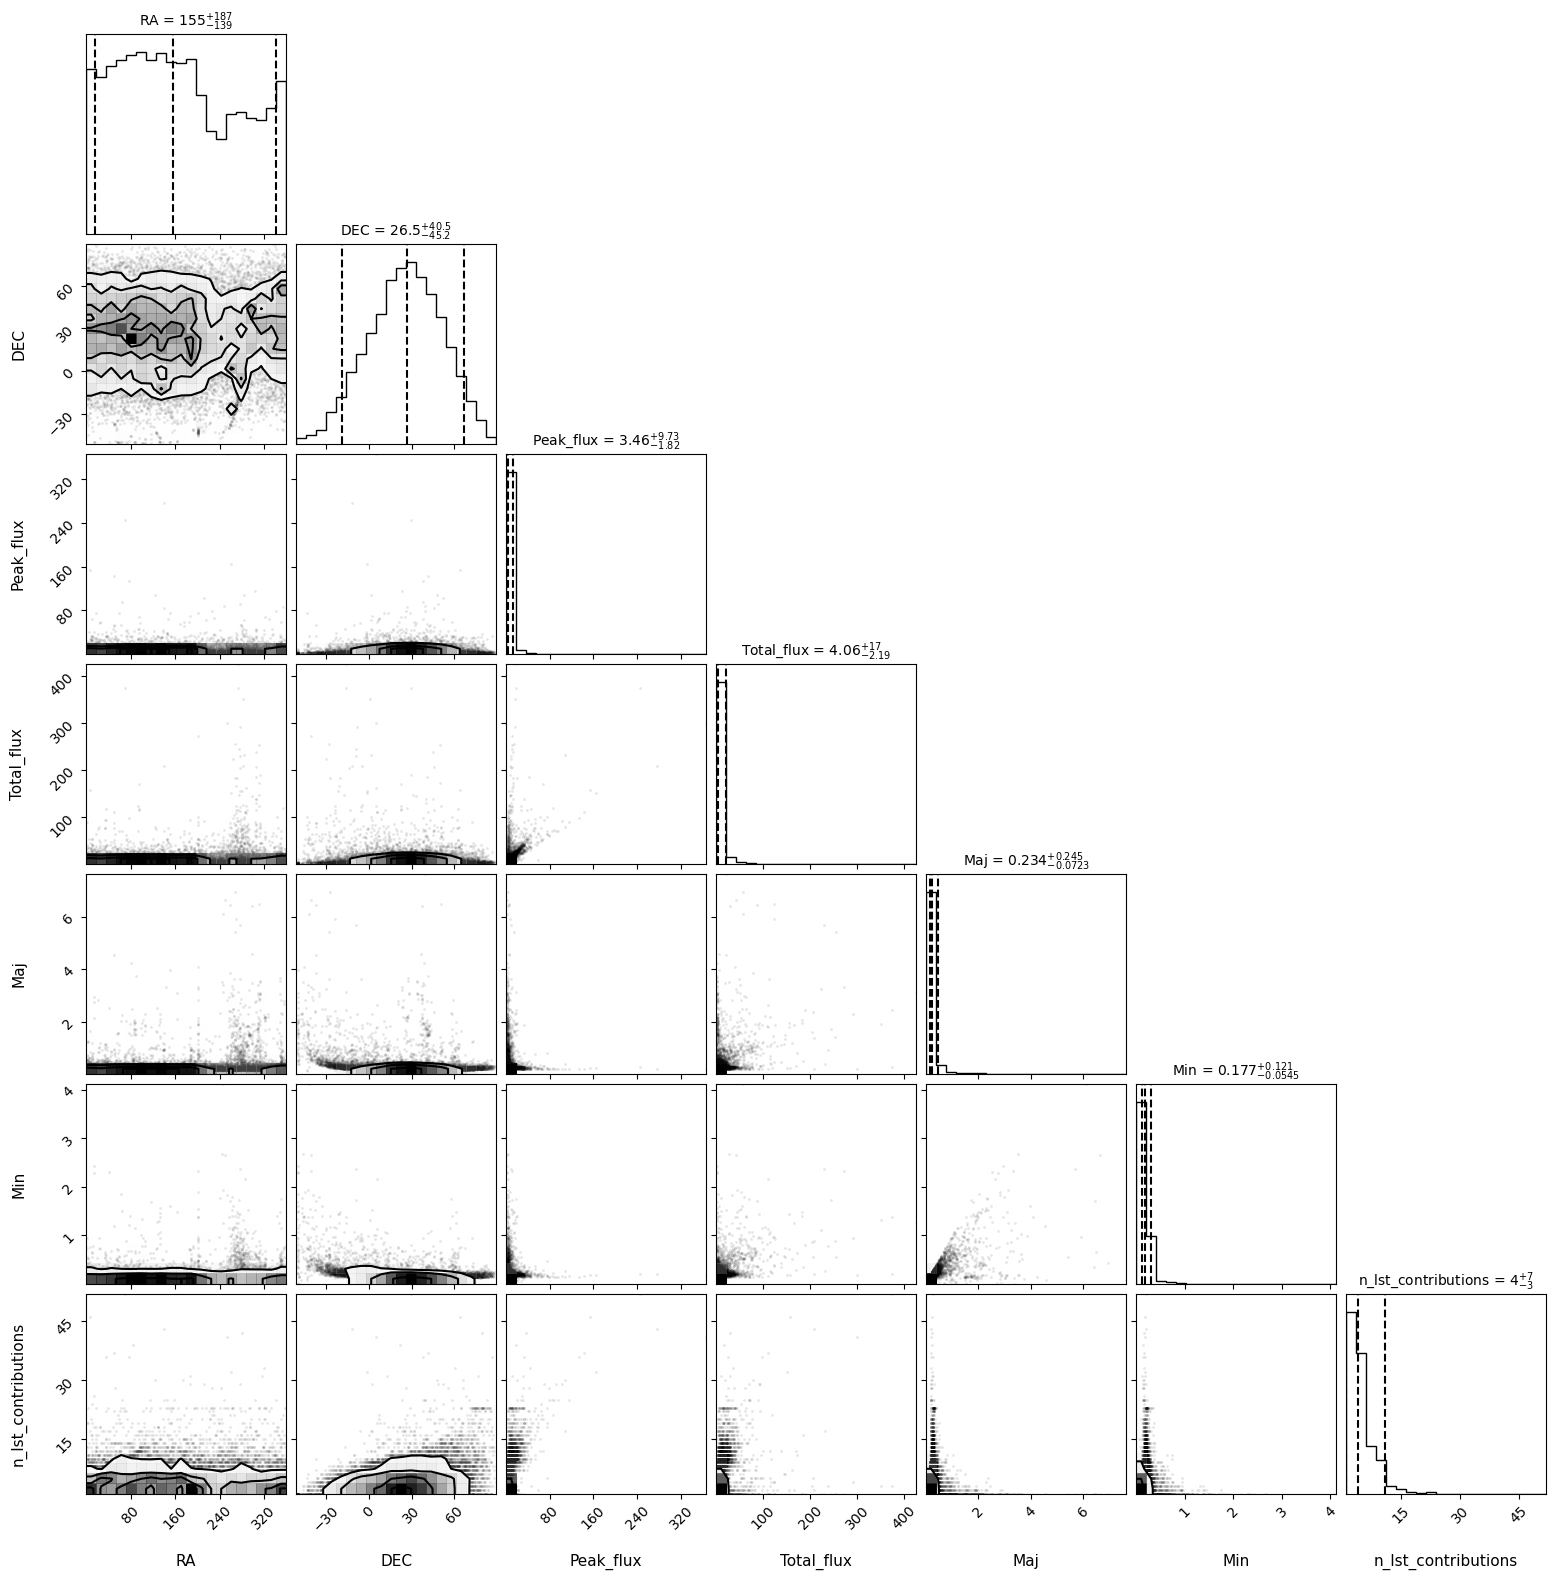

In [27]:
import corner
import matplotlib.pyplot as plt

cols = ["RA", "DEC", "Peak_flux", "Total_flux", "Maj", "Min", "n_lst_contributions"]

# drop NaNs; corner needs a clean numeric array
data = metacatalog[cols].dropna().to_numpy()

fig = corner.corner(
    data,
    labels=cols,
    quantiles=[0.05, 0.5, 0.95],
    show_titles=True,
    title_fmt=".3g",
    title_kwargs={"fontsize": 10},
    label_kwargs={"fontsize": 11},
)

# Save before show — Cursor/VS Code often cannot "download" inline plot images.
#OUT_PNG = OUTPUT_DIR / "metacatalog_corner.png"
#fig.savefig(OUT_PNG, dpi=150, bbox_inches="tight")
#print(f"Wrote {OUT_PNG}")
plt.show()


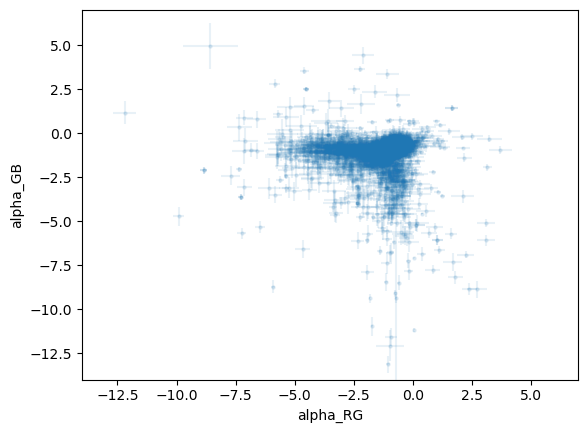

In [29]:
cols = ['meta_id', 'alpha_RG', 'E_alpha_RG', 'alpha_GB', 'E_alpha_GB']
data = metacatalog[cols].dropna(how='any')
ax = data.plot(x='alpha_RG', y='alpha_GB', xerr='E_alpha_RG', yerr='E_alpha_GB', marker='.', kind='scatter',
               alpha=0.1, xlim=[-14,7], ylim=[-14,7])
OUT_PNG = OUTPUT_DIR / "metacatalog_alpha.png"
ax.figure.savefig(OUT_PNG, dpi=150, bbox_inches="tight")

In [36]:
meta_ids = data[(data['alpha_RG']>1) & (data['alpha_GB']<-2)]['meta_id']

In [37]:
metacatalog.set_index('meta_id').loc[meta_ids].reset_index()

,meta_id,origin_band,bands_present,RA,DEC,Peak_flux,Total_flux,Maj,Min,PA,...,n_assoc_Red,BMAJ_full,source_file_Full,source_file_Blue,source_file_Green,source_file_Red,alpha_RG,E_alpha_RG,alpha_GB,E_alpha_GB
0,61,Full,"Full,Blue,Green,Red",305.459138,40.525969,41.794040,184.362329,0.488948,0.351042,31.380751,...,1,0.235147,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,1.034038,0.102749,-15.418100,0.535476
1,109,Full,"Full,Blue,Green,Red",304.843758,40.176355,33.143522,138.567970,0.464734,0.350022,142.487241,...,1,0.235147,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,1.259848,0.110589,-3.546013,0.084960
2,180,Full,"Full,Blue,Green,Red",269.908513,-23.589717,27.924319,114.198419,0.572164,0.553703,177.027027,...,1,0.233604,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,1.061152,0.140428,-3.322357,0.098309
3,722,Full,"Full,Blue,Green,Red",271.498061,-21.352850,14.246522,50.093914,0.522786,0.510990,11.758871,...,1,0.233604,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,2.238027,0.372799,-6.898849,0.208849
4,781,Full,"Full,Blue,Green,Red",300.161195,40.601877,13.728145,24.930965,0.354723,0.217605,166.855592,...,1,0.230495,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,2.402086,0.312484,-8.860207,0.358853
5,1688,Full,"Full,Blue,Green,Red",34.477010,62.051325,9.116973,93.191330,0.715393,0.606172,83.983709,...,1,0.227233,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,1.615637,0.240274,-5.709079,0.293554
6,1863,Full,"Full,Blue,Green,Red",0.020058,62.296537,8.678306,30.002409,0.530806,0.279737,41.771577,...,1,0.226296,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,1.121161,0.229339,-6.618957,0.219012
7,1902,Full,"Full,Blue,Green,Red",175.810296,20.027701,8.577472,29.637038,0.472708,0.280148,74.528519,...,1,0.226146,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,1.042825,0.224429,-6.067560,0.265812
8,2253,Full,"Full,Blue,Green,Red",300.129521,40.798845,7.853452,10.355250,0.307005,0.169116,105.006321,...,1,0.228941,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,1.793663,0.316362,-8.179454,0.363082
9,3107,Full,"Full,Blue,Green,Red",271.726901,-22.996091,6.541698,97.110695,1.870410,0.867131,36.411769,...,1,0.229482,Full_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Blue_I_deep_Taper_Robust+0.0_dewarped_aligned_...,Green_I_deep_Taper_Robust+0.0_dewarped_aligned...,Red_I_deep_Taper_Robust+0.0_dewarped_aligned_c...,3.100718,0.382016,-6.083677,0.323966
